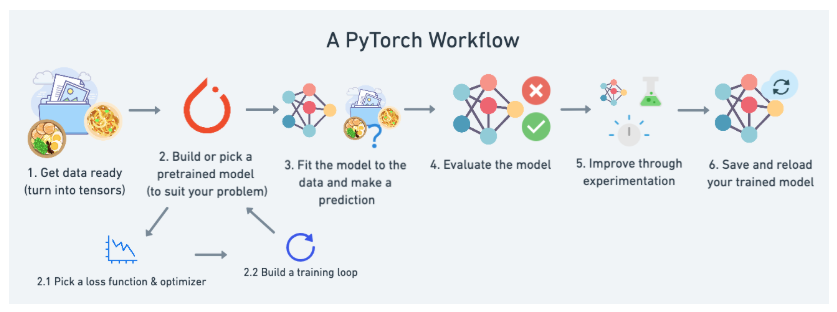

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## 1. Data (preparing and loading)

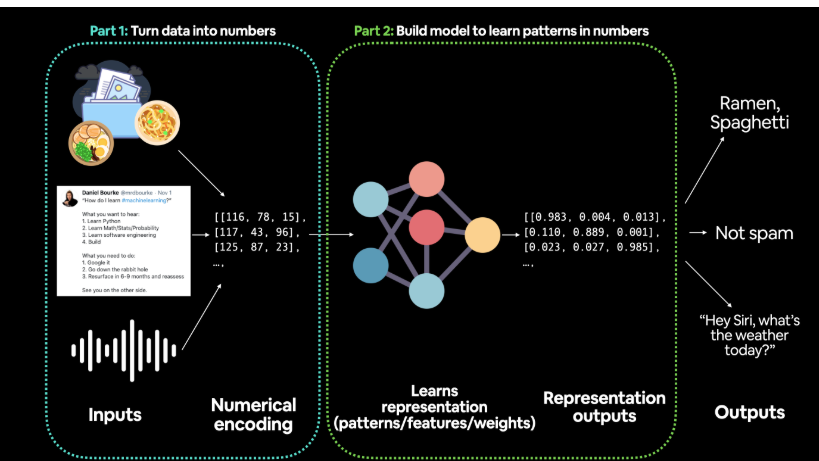

In [2]:
# Create known parameters
w = 0.7
b = 0.3

# Create a dataset
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).reshape(-1, 1) # (50, 1), reshape(-1, 1) makes it a column vector
y = w * X + b

In [3]:
X[:5], y[:5]  # Display first 5 samples

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

### Split data into training and test sets

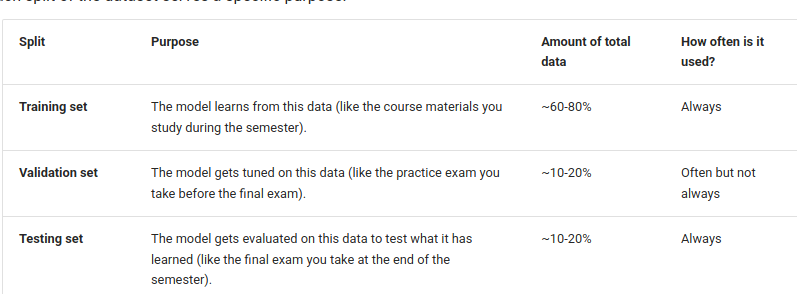
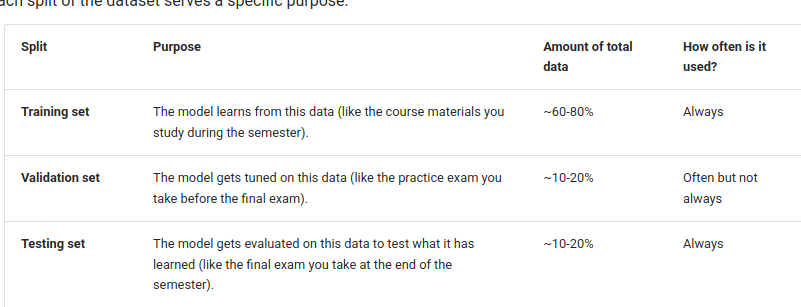

In [4]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)  # Display lengths of the splits

(40, 10, 40, 10)

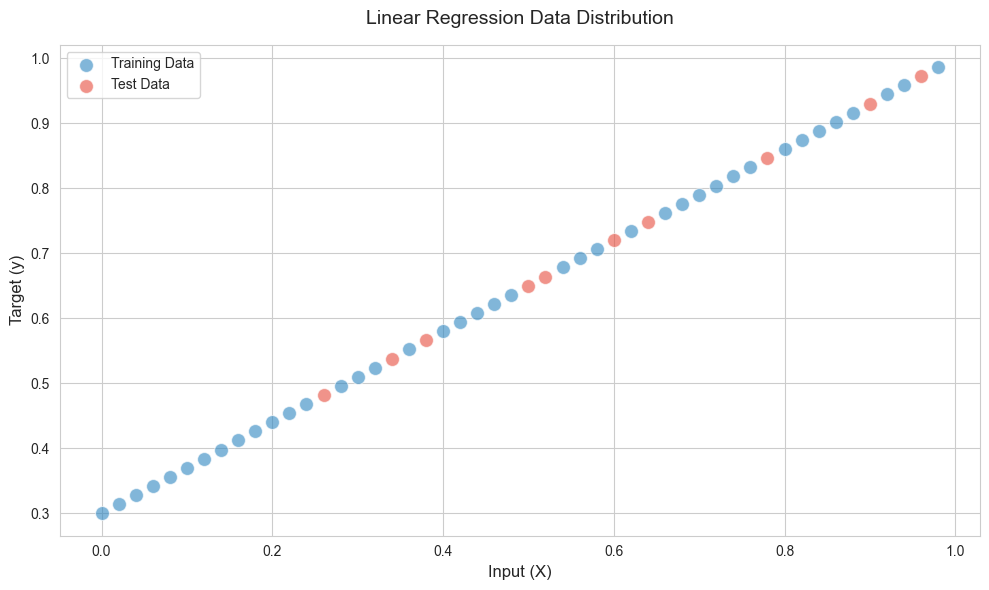

In [5]:
import seaborn as sns

def plot_data(X, y):
    # Set the style
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Create scatter plot with seaborn
    sns.scatterplot(x=X.flatten(), y=y.flatten(), color='#2E86C1', s=100, alpha=0.6, label='Training Data')
    # Test data
    sns.scatterplot(x=X_test.flatten(), y=y_test.flatten(), color='#E74C3C', s=100, alpha=0.6, label='Test Data')
    
    # Add title and labels with better formatting
    plt.title('Linear Regression Data Distribution', fontsize=14, pad=15)
    plt.xlabel('Input (X)', fontsize=12)
    plt.ylabel('Target (y)', fontsize=12)
    
    # Customize legend
    plt.legend(fontsize=10)
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

# Plot the training data
plot_data(X_train, y_train)

## 2. Build model

In [6]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

### PyTorch model building essentials

PyTorch has four fundamental modules that serve as building blocks for creating neural networks:

1. `torch.nn`: Neural network layers and activation functions
2. `torch.optim`: Optimization algorithms
3. `torch.utils.data.Dataset`: Data handling and custom datasets
4. `torch.utils.data.DataLoader`: Efficient data loading and batching

These modules provide the essential tools for building and training neural networks of any complexity.

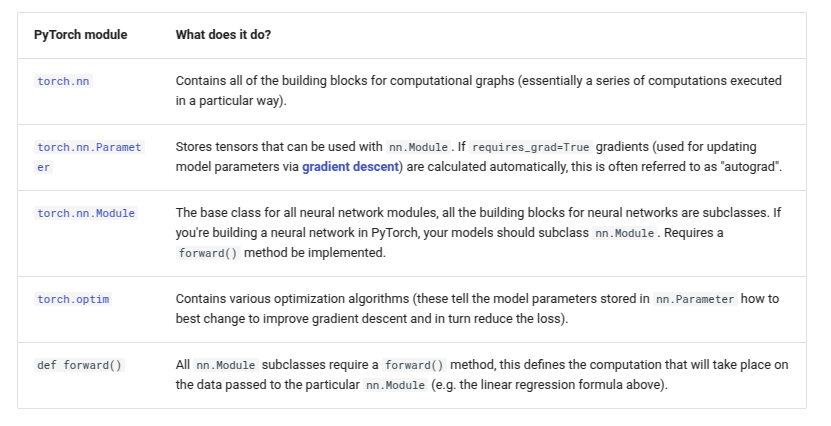

If the above sounds complex, think of it like this, almost everything in a PyTorch neural network comes from `torch.nn`:

* `nn.Module` contains the larger building blocks (layers)
* `nn.Parameter` contains the smaller parameters like weights and biases (put these together to make `nn.Module(s)`)
* `forward()` tells the larger blocks how to make calculations on inputs (tensors full of data) within `nn.Module(s)`
* `torch.optim` contains optimization methods on how to improve the parameters within `nn.Parameter` to better represent input data

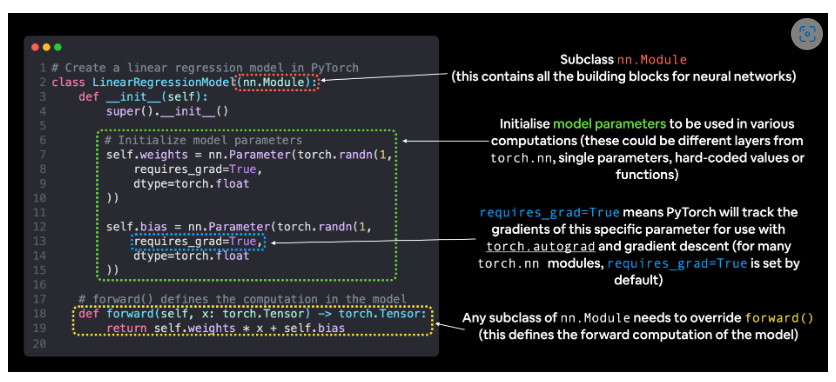

### Checking the contents of a PyTorch model

In [7]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
# List named parameters 
model_0.state_dict() # <- this is a dictionary of all the parameters in the model (weights and bias)

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using torch.inference_mode()

`torch.inference_mode()` is a context manager that optimizes model inference by:
* Disabling gradient tracking
* Disabling autograd engine
* Making forward passes faster
* Using less memory

This is similar to but more optimized than the older `torch.no_grad()`

In [9]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

In [10]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.2163],
        [0.3914],
        [0.3308],
        [0.4318],
        [0.2433],
        [0.4520],
        [0.3039],
        [0.2972],
        [0.3443],
        [0.2568]])


In [11]:
def plot_predictions(X_test, y_test, y_preds):
    # Set the style
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Create scatter plot with seaborn
    sns.scatterplot(x=X_test.flatten(), y=y_test.flatten(), color='#2E86C1', s=100, alpha=0.6, label='Test Data')
    
    # Create line plot for predictions
    sns.lineplot(x=X_test.flatten(), y=y_preds.flatten(), color='#E74C3C', linewidth=2, label='Predictions')
    
    # Add title and labels with better formatting
    plt.title('Linear Regression Predictions', fontsize=14, pad=15)
    plt.xlabel('Input (X)', fontsize=12)
    plt.ylabel('Target (y)', fontsize=12)
    
    # Customize legend
    plt.legend(fontsize=10)
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

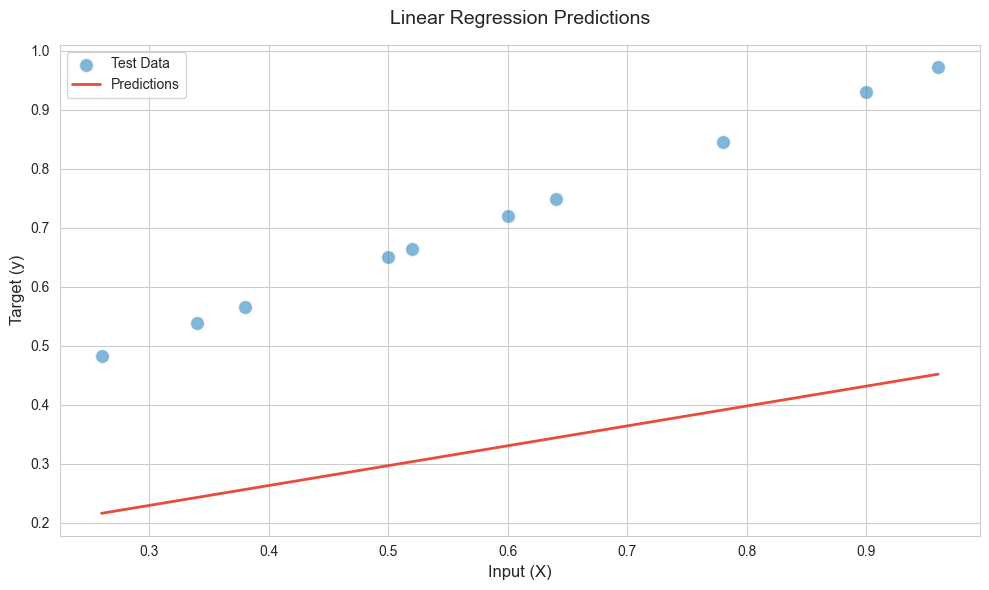

In [16]:
plot_predictions(X_test, y_test, y_preds)

In [12]:
y_test - y_preds # <- this is the difference between the true values and the predicted values

tensor([[0.2657],
        [0.4546],
        [0.3892],
        [0.4982],
        [0.2947],
        [0.5200],
        [0.3601],
        [0.3528],
        [0.4037],
        [0.3092]])

## 3. Train model

### Creating a loss function and optimizer in PyTorch

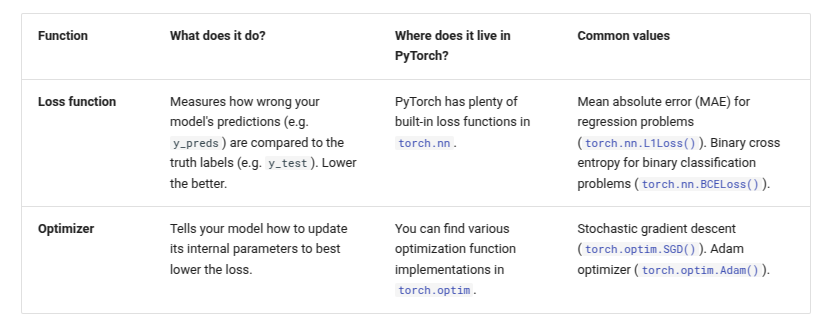

In [13]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), # parameters of target model to optimize
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

### Creating an optimization loop in PyTorch

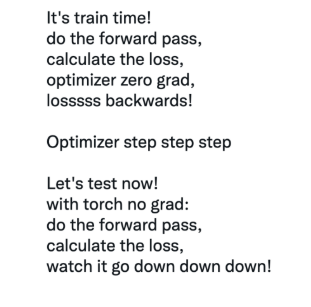

### PyTorch training loop

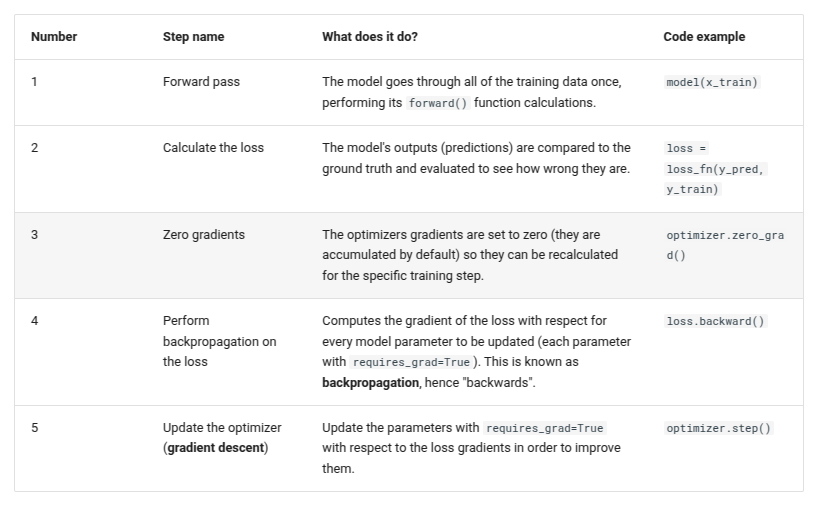

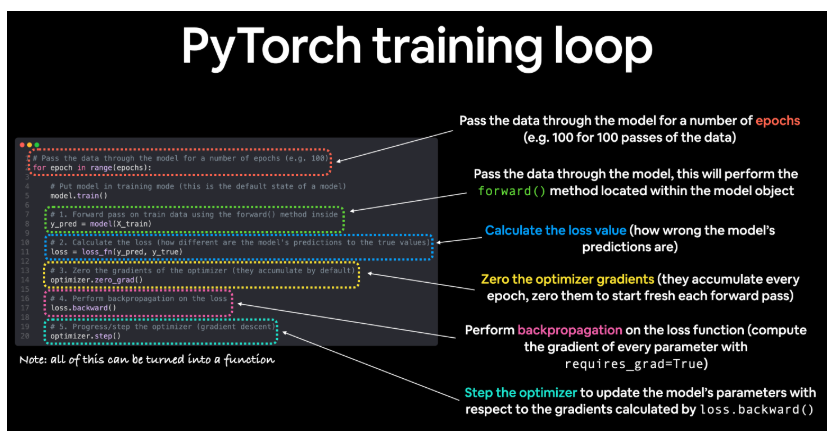

Rules of Thumb for Training Loop Order:

1. Calculate the loss (`loss = ...`) before backpropagation (`loss.backward()`)
2. Zero gradients (`optimizer.zero_grad()`) before computing gradients (`loss.backward()`) 
3. Step optimizer (`optimizer.step()`) after backpropagation (`loss.backward()`)

### PyTorch testing loop

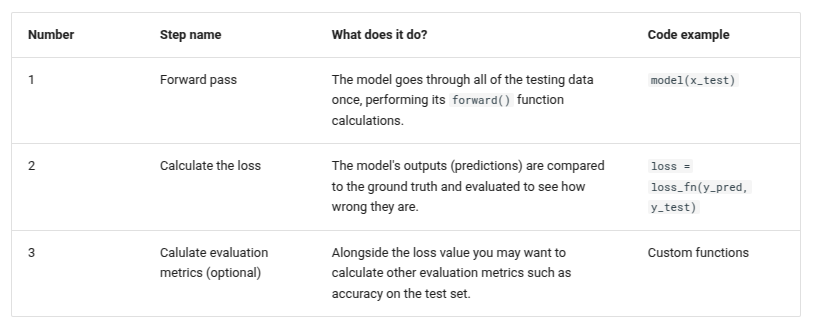

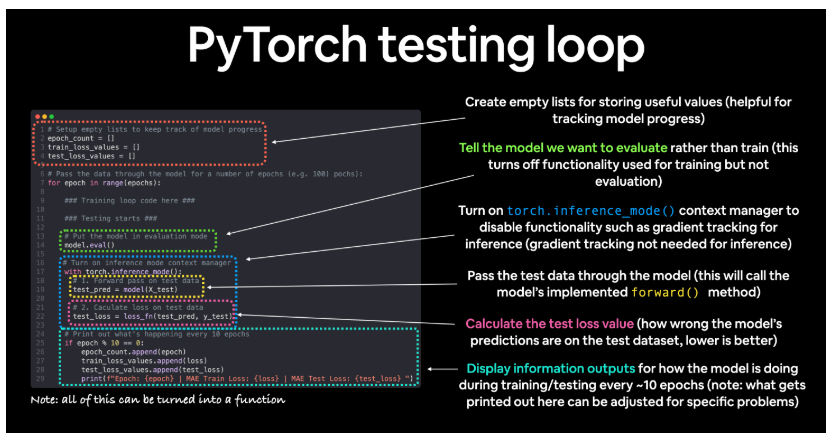

In [14]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.340311199426651 | MAE Test Loss: 0.3720795214176178 
Epoch: 10 | MAE Train Loss: 0.21864214539527893 | MAE Test Loss: 0.24470801651477814 
Epoch: 20 | MAE Train Loss: 0.10375527292490005 | MAE Test Loss: 0.12293665111064911 
Epoch: 30 | MAE Train Loss: 0.06399796903133392 | MAE Test Loss: 0.06073009967803955 
Epoch: 40 | MAE Train Loss: 0.05161098390817642 | MAE Test Loss: 0.04132990166544914 
Epoch: 50 | MAE Train Loss: 0.04540504142642021 | MAE Test Loss: 0.03398849442601204 
Epoch: 60 | MAE Train Loss: 0.03980403393507004 | MAE Test Loss: 0.029580067843198776 
Epoch: 70 | MAE Train Loss: 0.034203048795461655 | MAE Test Loss: 0.02517164871096611 
Epoch: 80 | MAE Train Loss: 0.028602052479982376 | MAE Test Loss: 0.020763223990797997 
Epoch: 90 | MAE Train Loss: 0.02300105430185795 | MAE Test Loss: 0.016354799270629883 


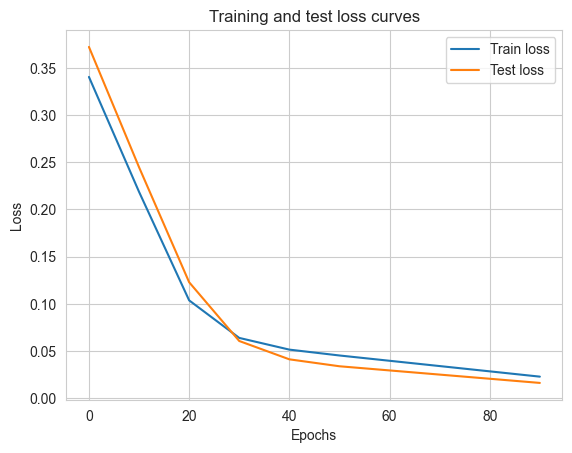

In [15]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [16]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {w}, bias: {b}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.6344]), 'bias': tensor([0.3333])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


## 4. Making predictions with a trained PyTorch model (inference)

In [17]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
y_preds

tensor([[0.4983],
        [0.8281],
        [0.7140],
        [0.9043],
        [0.5490],
        [0.9423],
        [0.6632],
        [0.6505],
        [0.7393],
        [0.5744]])

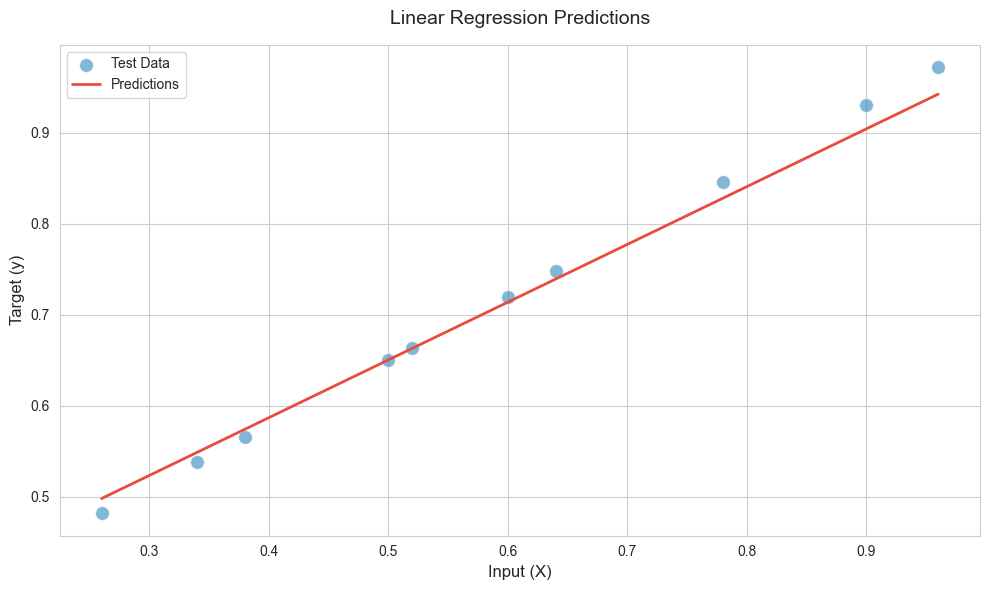

In [18]:
plot_predictions(X_test, y_test, y_preds)

## 5. Saving and loading a PyTorch model

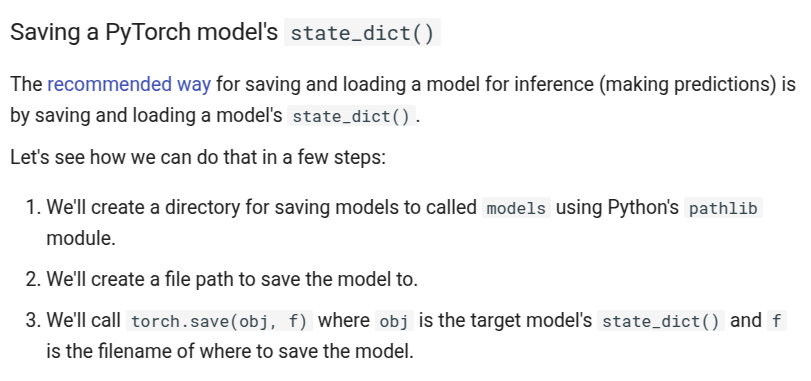

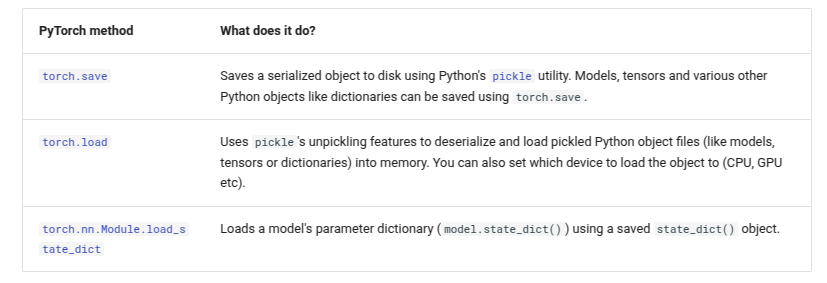

### Saving a PyTorch model's state_dict()

In [19]:
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path 
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH) 

Saving model to: models/01_pytorch_workflow_model_0.pth


In [20]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth

-rwxr-xr-x 1 nafiz nafiz 1680 Mar 29 13:48 models/01_pytorch_workflow_model_0.pth


### Loading a saved PyTorch model's state_dict()

In [21]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

/tmp/ipykernel_10028/1296048670.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [22]:
# 1. Put the loaded model into evaluation mode
loaded_model_0.eval()

# 2. Use the inference mode context manager to make predictions
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) # perform a forward pass on the test data with the loaded model

In [23]:
# Compare previous model predictions with loaded model predictions (these should be the same)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])